In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import auc
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv('C:\Program Files\Merrimack\DSE6211\Project\project_data.csv')
df = data.drop('Booking_ID', axis=1) 

In [5]:
X = df.drop('booking_status', axis=1)
y = df['booking_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=123)

In [6]:
encoder = OneHotEncoder(handle_unknown='ignore')
encoder.fit(X_train[['market_segment_type', 'lead_time', 'type_of_meal_plan', 'room_type_reserved', 'arrival_date',
                     'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'required_car_parking_space', 'repeated_guest', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']])
encoded_df = pd.DataFrame(encoder.transform(X_train[['market_segment_type', 'lead_time', 'type_of_meal_plan', 'room_type_reserved', 'arrival_date',
                     'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'required_car_parking_space', 'repeated_guest', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']]).toarray(),
                          columns=encoder.get_feature_names_out(['market_segment_type', 'lead_time', 'type_of_meal_plan', 'room_type_reserved', 'arrival_date',
                     'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'required_car_parking_space', 'repeated_guest', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']))
X_train = pd.concat([X_train.drop(['market_segment_type', 'lead_time', 'type_of_meal_plan', 'room_type_reserved', 'arrival_date',
                     'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'required_car_parking_space', 'repeated_guest', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests'], axis=1).reset_index(drop=True), encoded_df], axis=1)
X_train.columns

Index(['market_segment_type_aviation', 'market_segment_type_complementary',
       'market_segment_type_corporate', 'market_segment_type_offline',
       'market_segment_type_online', 'lead_time_0', 'lead_time_1',
       'lead_time_2', 'lead_time_3', 'lead_time_4',
       ...
       'avg_price_per_room_349.63', 'avg_price_per_room_365.0',
       'avg_price_per_room_375.5', 'avg_price_per_room_540.0',
       'no_of_special_requests_0', 'no_of_special_requests_1',
       'no_of_special_requests_2', 'no_of_special_requests_3',
       'no_of_special_requests_4', 'no_of_special_requests_5'],
      dtype='object', length=4373)

In [7]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [8]:
X_train_scaled.head()

,market_segment_type_aviation,market_segment_type_complementary,market_segment_type_corporate,market_segment_type_offline,market_segment_type_online,lead_time_0,lead_time_1,lead_time_2,lead_time_3,lead_time_4,...,avg_price_per_room_349.63,avg_price_per_room_365.0,avg_price_per_room_375.5,avg_price_per_room_540.0,no_of_special_requests_0,no_of_special_requests_1,no_of_special_requests_2,no_of_special_requests_3,no_of_special_requests_4,no_of_special_requests_5
0,-0.056669,-0.105648,-0.243564,1.564504,-1.332491,-0.192487,-0.174822,-0.135922,-0.134795,-0.135218,...,-0.006066,-0.006066,-0.006066,-0.006066,0.914048,-0.675059,-0.370986,-0.138151,-0.047038,-0.01486
1,-0.056669,-0.105648,-0.243564,-0.639180,0.750474,-0.192487,-0.174822,7.357159,-0.134795,-0.135218,...,-0.006066,-0.006066,-0.006066,-0.006066,-1.094035,1.481353,-0.370986,-0.138151,-0.047038,-0.01486
2,-0.056669,-0.105648,-0.243564,1.564504,-1.332491,-0.192487,-0.174822,-0.135922,-0.134795,-0.135218,...,-0.006066,-0.006066,-0.006066,-0.006066,-1.094035,1.481353,-0.370986,-0.138151,-0.047038,-0.01486
3,-0.056669,-0.105648,-0.243564,1.564504,-1.332491,-0.192487,-0.174822,-0.135922,-0.134795,-0.135218,...,-0.006066,-0.006066,-0.006066,-0.006066,0.914048,-0.675059,-0.370986,-0.138151,-0.047038,-0.01486
4,-0.056669,-0.105648,-0.243564,-0.639180,0.750474,-0.192487,-0.174822,-0.135922,-0.134795,-0.135218,...,-0.006066,-0.006066,-0.006066,-0.006066,-1.094035,1.481353,-0.370986,-0.138151,-0.047038,-0.01486


In [9]:
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)


In [10]:
X_train_tensor

tensor([[-0.0567, -0.1056, -0.2436,  ..., -0.1382, -0.0470, -0.0149],
        [-0.0567, -0.1056, -0.2436,  ..., -0.1382, -0.0470, -0.0149],
        [-0.0567, -0.1056, -0.2436,  ..., -0.1382, -0.0470, -0.0149],
        ...,
        [-0.0567, -0.1056, -0.2436,  ..., -0.1382, -0.0470, -0.0149],
        [-0.0567, -0.1056, -0.2436,  ..., -0.1382, -0.0470, -0.0149],
        [-0.0567, -0.1056,  4.1057,  ..., -0.1382, -0.0470, -0.0149]])

In [11]:
encoded_df = pd.DataFrame(encoder.transform(X_test[['market_segment_type', 'lead_time', 'type_of_meal_plan', 'room_type_reserved', 'arrival_date',
                     'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'required_car_parking_space', 'repeated_guest', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']]).toarray(),
                          columns=encoder.get_feature_names_out(['market_segment_type', 'lead_time', 'type_of_meal_plan', 'room_type_reserved', 'arrival_date',
                     'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'required_car_parking_space', 'repeated_guest', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']))
X_test = pd.concat([X_test.drop(['market_segment_type', 'lead_time', 'type_of_meal_plan', 'room_type_reserved', 'arrival_date',
                     'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                    'required_car_parking_space', 'repeated_guest', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests'], axis=1).reset_index(drop=True), encoded_df], axis=1)
X_test.columns

Index(['market_segment_type_aviation', 'market_segment_type_complementary',
       'market_segment_type_corporate', 'market_segment_type_offline',
       'market_segment_type_online', 'lead_time_0', 'lead_time_1',
       'lead_time_2', 'lead_time_3', 'lead_time_4',
       ...
       'avg_price_per_room_349.63', 'avg_price_per_room_365.0',
       'avg_price_per_room_375.5', 'avg_price_per_room_540.0',
       'no_of_special_requests_0', 'no_of_special_requests_1',
       'no_of_special_requests_2', 'no_of_special_requests_3',
       'no_of_special_requests_4', 'no_of_special_requests_5'],
      dtype='object', length=4373)

In [12]:
scaler = StandardScaler()
scaler.fit(X_test)
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)

In [13]:
X_test_tensor = torch.tensor(X_test_scaled.values)
X_test_tensor.size()

torch.Size([9060, 4373])

In [14]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)  
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.float32)
y_test_encoded = encoder.fit_transform(y_test)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.float32)

In [15]:
y_train_tensor

tensor([1., 1., 0.,  ..., 1., 1., 0.])

In [16]:
y_test_tensor

tensor([1., 1., 1.,  ..., 1., 0., 1.])

In [17]:
y_test_np = y_test_tensor.numpy().reshape(-1, 1)  
scaler = StandardScaler()
scaler.fit(y_test_np)
y_test_scaled = scaler.transform(y_test_np)


In [18]:
X_test_np = X_test_scaled.to_numpy().astype(np.float32)
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)


In [19]:
n_samples = X_train_tensor.shape[0]
n_val = int(0.2 * n_samples)
shuffled_indices = torch.randperm(n_samples)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]
train_indices, val_indices

X_tr = X_train_tensor[train_indices]
y_tr = y_train_tensor[train_indices]
X_val = X_train_tensor[val_indices]
y_val = y_train_tensor[val_indices]

In [20]:
seq_model = nn.Sequential(
    nn.Linear(4373, 200),
    nn.ReLU(),
    nn.Linear(200, 100),
    nn.ReLU(),
    nn.Linear(100, 1),
    nn.Sigmoid()
)

In [21]:
def training_loop(n_epochs, optimizer, model, loss_fn, X_tr, X_val, y_tr, y_val, patience=15):
    best_val_loss = float("inf")
    counter = 0 

    for epoch in range(1, n_epochs + 1):
        seq_model.train() 

        X_tr_p = model(X_tr)
        loss_train = loss_fn(X_tr_p, y_tr.unsqueeze(1))

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        seq_model.eval()
        with torch.no_grad():
            X_val_p = model(X_val)
            loss_val = loss_fn(X_val_p, y_val.unsqueeze(1))


        if epoch == 1 or epoch % 10 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f}, Validation loss {loss_val.item():.4f}")

        if loss_val.item() < best_val_loss:
            best_val_loss = loss_val.item()
            counter = 0  
        else:
            counter += 1  

        if counter >= patience:
            print(f"Overfitting detected at epoch {epoch}. Training concluded.")
            print(f"Final Epoch: {epoch}, Training Loss: {loss_train.item():.4f}, Validation Loss: {loss_val.item():.4f}")
            break


In [22]:
optimizer = optim.RMSprop(seq_model.parameters(), lr=1e-4)
training_loop(
    n_epochs = 200,
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.BCELoss(),
    X_tr = X_tr,
    X_val = X_val,
    y_tr = y_tr,
    y_val = y_val)

Epoch 1, Training loss 0.7125, Validation loss 0.6757
Epoch 10, Training loss 0.4981, Validation loss 0.5556
Epoch 20, Training loss 0.3860, Validation loss 0.4976
Epoch 30, Training loss 0.3205, Validation loss 0.4720
Epoch 40, Training loss 0.2781, Validation loss 0.4610
Epoch 50, Training loss 0.2470, Validation loss 0.4563
Epoch 60, Training loss 0.2217, Validation loss 0.4543
Epoch 70, Training loss 0.2000, Validation loss 0.4537
Epoch 80, Training loss 0.1808, Validation loss 0.4540
Early stopping triggered at epoch 87. Training stopped.
Final Epoch: 87, Training Loss: 0.1685, Validation Loss: 0.4547


In [23]:
seq_model(X_test_tensor).detach().numpy()

array([[0.78787166],
       [0.9671501 ],
       [0.9661977 ],
       ...,
       [0.94713265],
       [0.0328461 ],
       [0.65751475]], shape=(9060, 1), dtype=float32)

In [24]:
p_1_actual = pd.DataFrame({'p_1': seq_model(X_test_tensor).detach().numpy().reshape(-1), 'actual': y_test_encoded})
p_1_actual.head()

,p_1,actual
0,0.787872,1
1,0.967150,1
2,0.966198,1
3,0.759832,1
4,0.988461,1


In [25]:
roc_list = []

actuals_0 = (p_1_actual['actual'] == 0).sum()
actuals_1 = (p_1_actual['actual'] == 1).sum()

for i in np.arange(1, -0.01, -0.01):

    over_threshold = p_1_actual[p_1_actual['p_1'] >= i]
    
    fp = (over_threshold['actual'] == 0).sum()
    tp = (over_threshold['actual'] == 1).sum()

    fpr = fp / actuals_0 if actuals_0 > 0 else 0.0
    tpr = tp / actuals_1 if actuals_1 > 0 else 0.0
    
    roc_list.append((i, fpr, tpr))

roc_data = pd.DataFrame(roc_list, columns=['threshold', 'fpr', 'tpr'])

roc_data
  

,threshold,fpr,tpr
0,1.000000e+00,0.000000,0.000000
1,9.900000e-01,0.007853,0.103572
2,9.800000e-01,0.018436,0.178601
3,9.700000e-01,0.026630,0.241722
4,9.600000e-01,0.032434,0.284782
...,...,...,...
96,4.000000e-02,0.878115,0.996575
97,3.000000e-02,0.930352,0.996901
98,2.000000e-02,0.969273,0.997717
99,1.000000e-02,0.989075,0.999348


In [26]:
roc_auc = auc(roc_data['fpr'], roc_data['tpr'])
print(f"ROC AUC Score: {roc_auc:.4f}")

ROC AUC Score: 0.8849


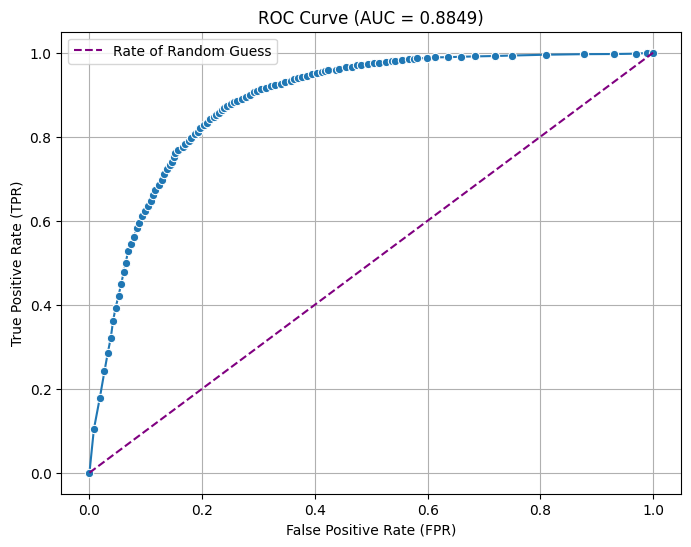

In [27]:
plt.figure(figsize=(8, 6))
roc = sns.lineplot(x='fpr', y='tpr', data=roc_data, marker='o', linestyle='-')

xlims = roc.get_xlim()
ylims = roc.get_ylim()

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.plot([0, 1], [0, 1], linestyle='--', color='purple', label="Rate of Random Guess")

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'ROC Curve (AUC = {roc_auc:.4f})') 
plt.legend()
plt.grid()

plt.show()

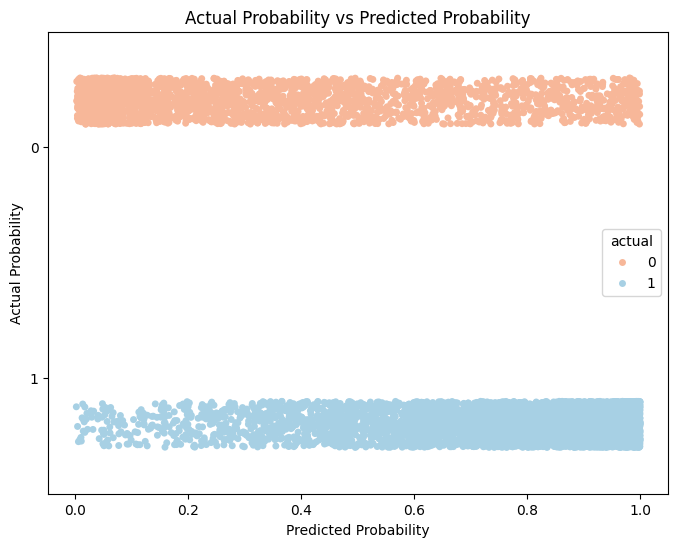

In [28]:
p_1_actual['actual'] = p_1_actual['actual'].astype('category')

plt.figure(figsize=(8,6))
strip = sns.stripplot(x='p_1', y='actual', data=p_1_actual, jitter=0.2, hue='actual', palette='RdBu', dodge=True)

plt.title('Actual Probability vs Predicted Probability')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Probability')

plt.show()